# imports

In [169]:
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

import matplotlib.pyplot as plt
import seaborn as sns


In [170]:
# Path relative to Scripts/
data_dir = Path("../Data")
input_file = data_dir / "2026-07-13_2_bank_dataset_cleaned.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig", index_col=0)

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")

Dataset loaded from: C:\Users\nowan\Documents\itacademy\Simulador\ProjecteData\Equip_32\Data\2026-07-13_2_bank_dataset_cleaned.csv
Shape: (10975, 19)


In [171]:
df = df.reset_index()  # converteix l'índex en columna normal
df.rename(columns={'index': 'id'}, inplace=True)  # per si el nom no és 'id'

In [172]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,no_previous_contact,had_previous_contact
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1,1,0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1381,1,-1,0,unknown,1,1,0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1381,1,-1,0,unknown,1,1,0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1,1,0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10970,10983,40.0,management,married,secondary,no,8486,no,no,unknown,6,may,260,3,-1,0,unknown,0,1,0
10971,10984,53.0,management,married,tertiary,no,20772,no,no,cellular,4,feb,715,1,-1,0,unknown,0,1,0
10972,10985,55.0,blue-collar,married,primary,no,3297,yes,yes,telephone,30,apr,96,1,-1,0,unknown,0,1,0
10973,10986,41.0,management,married,tertiary,no,9,yes,no,cellular,22,jul,82,3,-1,0,unknown,0,1,0


# Data Transformations

# 1 Demografical clustering

## Age group

In [173]:
# Age_group
bins   = [17, 25, 35, 50, 65, 100]
labels = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True    # right-closed intervals: (17,25] includes 25
)

In [174]:
counts = df["age_group"].value_counts().sort_index()
print(counts)
print(f"\nUnassigned (NaN): {df['age_group'].isna().sum()}")

age_group
Young (18-25)           444
Young Adult (26-35)    3840
Adult (36-50)          4255
Middle-Aged (51-65)    2039
Senior (65+)            397
Name: count, dtype: int64

Unassigned (NaN): 0


In [175]:
age_summary = (
    df.groupby("age_group", observed=True)["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

age_summary["n_clients"] = df.groupby("age_group", observed=True).size()
print(age_summary)

deposit              pct_no  pct_yes  n_clients
age_group                                      
Young (18-25)        0.2815   0.7185        444
Young Adult (26-35)  0.5138   0.4862       3840
Adult (36-50)        0.5803   0.4197       4255
Middle-Aged (51-65)  0.5135   0.4865       2039
Senior (65+)         0.1965   0.8035        397


## Vinculacion financiera

In [176]:
# Vinculación financiera

# "unknown" is treated as 0 (no burden assumed)
# This is a deliberate modelling choice — document it in the notebook

product_map = {"yes": 1, "no": 0, "unknown": 0}

df["housing_score"]  = df["housing"].map(product_map)
df["loan_score"]     = df["loan"].map(product_map)

In [177]:
df["vinculacion"] = (
    df["housing_score"] +
    df["loan_score"] + 
    df["deposit"]
)

In [178]:
vinculacion_labels = {
    0: "0 productos",
    1: "1 producto",
    2: "multiproducto 2",
    3: "multiproducto 3"
    
}

In [180]:
vinculacion_summary = (
    df.groupby("vinculacion")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

vinculacion_summary["n_clients"] = df.groupby("vinculacion").size()


print(vinculacion_summary)

deposit      pct_no  pct_yes  n_clients
vinculacion                            
0            1.0000      NaN       2054
1            0.4963   0.5037       6216
2            0.2266   0.7734       2440
3               NaN   1.0000        265


In [181]:
# Detall de productos por cliente (columna categórica, no solo el conteo)
df["housing_bin"] = (df["housing"] == "yes").astype(int)
df["loan_bin"] = (df["loan"] == "yes").astype(int)
df["deposit_bin"] = df["deposit"]  # ya es 0/1

def detalle_productos(row):
    productos = []
    if row["housing_bin"] == 1:
        productos.append("Hipoteca")
    if row["loan_bin"] == 1:
        productos.append("Préstamo")
    if row["deposit_bin"] == 1:
        productos.append("Depósito")
    return " + ".join(productos) if productos else "Ninguno"

df["productos_detalle"] = df.apply(detalle_productos, axis=1)

print(df["productos_detalle"].value_counts())

productos_detalle
Depósito                          3131
Hipoteca                          2694
Ninguno                           2054
Hipoteca + Depósito               1669
Hipoteca + Préstamo                553
Préstamo                           391
Hipoteca + Préstamo + Depósito     265
Préstamo + Depósito                218
Name: count, dtype: int64


In [182]:
#filto multiproducto
multiproducto = df[df["productos_detalle"].isin([
    "Hipoteca + Préstamo",
    "Hipoteca + Depósito",
    "Préstamo + Depósito",
    "Hipoteca + Préstamo + Depósito"
])]

## Education

In [183]:
# education

print(df["education"].value_counts())
print(f"\nUnknown count: {(df['education'] == 'unknown').sum()}")


education
secondary    5385
tertiary     3637
primary      1466
unknown       487
Name: count, dtype: int64

Unknown count: 487


In [184]:
# Ordinal scale: unknown → NaN (excluded from ranking)
# primary=1, secondary=2, tertiary=3

education_order = {
    "primary"   : 1,
    "secondary" : 2,
    "tertiary"  : 3,
    "unknown"   : None
}

df["education_rank"] = df["education"].map(education_order)

In [185]:
education_labels = {
    "primary"   : "Primary",
    "secondary" : "Secondary",
    "tertiary"  : "Tertiary",
    "unknown"   : "Unknown"
}

df["education_label"] = df["education"].map(education_labels)

In [186]:
edu_summary = (
    df.groupby("education_label")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

edu_summary["n_clients"] = df.groupby("education_label").size()

# Sort by ordinal rank
order = ["Primary", "Secondary", "Tertiary", "Unknown"]
edu_summary = edu_summary.reindex(order)
print(edu_summary)

deposit          pct_no  pct_yes  n_clients
education_label                            
Primary          0.5969   0.4031       1466
Secondary        0.5456   0.4544       5385
Tertiary         0.4520   0.5480       3637
Unknown          0.4825   0.5175        487


## Jobs

In [187]:
#jobs

print(df["job"].value_counts())
print(f"\nUnknown count: {(df['job'] == 'unknown').sum()}")

job
management       2531
blue-collar      1904
technician       1791
admin.           1317
services          905
retired           769
self-employed     398
student           358
unemployed        346
entrepreneur      319
housemaid         267
unknown            70
Name: count, dtype: int64

Unknown count: 70


In [188]:
job_profile_map = {
    "admin."       : "White Collar",
    "management"   : "White Collar",
    "technician"   : "White Collar",
    "blue-collar"  : "Blue Collar",
    "housemaid"    : "Blue Collar",
    "services"     : "Blue Collar",
    "entrepreneur" : "Self-Employed",
    "self-employed": "Self-Employed",
    "retired"      : "Retired",
    "student"      : "Student",
    "unemployed"   : "Unemployed",
    "unknown"      : "Unknown"
}

df["job_profile"] = df["job"].map(job_profile_map)

In [189]:
job_summary = (
    df.groupby("job_profile")["deposit"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={1: "pct_yes", 0: "pct_no"})
    .round(4)
)

job_summary["n_clients"] = df.groupby("job_profile").size()

order = ["White Collar", "Blue Collar", "Self-Employed", "Unemployed", "Retired", "Student", "Unknown"]
job_summary = job_summary.reindex(order)
print(job_summary)

deposit        pct_no  pct_yes  n_clients
job_profile                              
White Collar   0.5091   0.4909       5639
Blue Collar    0.6144   0.3856       3076
Self-Employed  0.5676   0.4324        717
Unemployed     0.4162   0.5838        346
Retired        0.3303   0.6697        769
Student        0.2514   0.7486        358
Unknown        0.5143   0.4857         70


In [190]:
month_map = {
    'jan': 'January', 'feb': 'February', 'mar': 'March',
    'apr': 'April', 'may': 'May', 'jun': 'June',
    'jul': 'July', 'aug': 'August', 'sep': 'September',
    'oct': 'October', 'nov': 'November', 'dec': 'December'
}
df['month'] = df['month'].map(month_map)

In [191]:
df['week_of_month'] = ((df['day'] - 1) // 7) + 1
# Resultat: 1, 2, 3, 4, 5

In [192]:
bins = [0, 3, 10, 20, 30, float('inf')]
labels = ['0-3', '4-10', '11-20', '21-30', '+30']
df['campaign_group'] = pd.cut(df['campaign'], bins=bins, labels=labels)

In [193]:
# Opció 2: Reset de l'índex com a columna neta
df = df.reset_index(drop=True)
df.index = df.index + 1  # comença des de 1 en lloc de 0


# Clusteritzacions

## ## Clusteritació amb k-prototiper directa + segments students/retired

In [194]:

# 2. Separar els segments de regla de negoci
df_rest = df[~df['job_profile'].isin(['Student', 'Retired'])].copy()

print(f"Total dataset: {len(df)}")
print(f"Excloent Student i Retired: {len(df_rest)}")
print(df['job_profile'].value_counts())

Total dataset: 10975
Excloent Student i Retired: 9848
job_profile
White Collar     5639
Blue Collar      3076
Retired           769
Self-Employed     717
Student           358
Unemployed        346
Unknown            70
Name: count, dtype: int64


In [195]:
# 3. Seleccionar variables d'identitat (sense engagementn, balance, ni variables de campanya)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df_rest[cluster_vars].copy()

# 4. Comprovar que no hi ha nulls abans d'escalar/clusteritzar
print(df_cluster.isna().sum())

# 5. Escalar age
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

print(df_cluster[['age', 'age_scaled']].head())

age                0
job_profile        0
education_label    0
marital            0
dtype: int64
    age  age_scaled
1  59.0    1.964237
2  56.0    1.655520
3  41.0    0.111934
4  55.0    1.552614
5  54.0    1.449708


In [196]:
# 6. Preparar la matriu X: age_scaled primer, després les 3 categòriques
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values

# 7. Indicar les posicions (índexs de columna dins de X) que són categòriques
categorical_idx = [1, 2, 3]  # job_profile, education_label, marital

print(X.shape)
print(X[:3])  # primeres 3 files, per veure que la matriu té la pinta correcta

(9848, 4)
[[1.964236912718694 'White Collar' 'Secondary' 'married']
 [1.655519760798443 'White Collar' 'Secondary' 'married']
 [0.11193400119718808 'White Collar' 'Secondary' 'married']]


In [197]:
# 8. Elbow method: provar k de 2 a 7
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

k=2 -> cost=9468.2
k=3 -> cost=7481.9
k=4 -> cost=6439.7
k=5 -> cost=5777.7
k=6 -> cost=5484.2
k=7 -> cost=5042.7


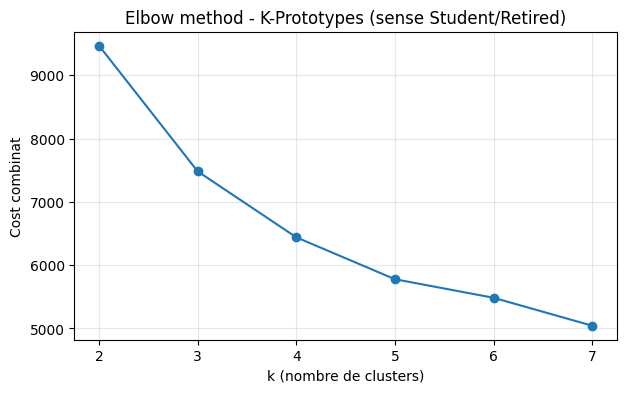

In [198]:

k_range = range(2, 8)
plt.figure(figsize=(7,4))
plt.plot(k_range, costs, marker='o')
plt.xlabel('k (nombre de clusters)')
plt.ylabel('Cost combinat')
plt.title('Elbow method - K-Prototypes (sense Student/Retired)')
plt.grid(True, alpha=0.3)
plt.show()

In [199]:
# 9. Model final amb k=4
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df_rest['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

print("Cost final:", kproto_final.cost_)
print(df_rest['cluster'].value_counts().sort_index())

Cost final: 6439.747077084839
cluster
0    2645
1    2292
2    2210
3    2701
Name: count, dtype: int64


In [200]:
# 10. Caracterització de cada cluster
for c in sorted(df_rest['cluster'].unique()):
    sub = df_rest[df_rest['cluster']==c]
    print(f"--- Cluster {c} (n={len(sub)}, {len(sub)/len(df_rest)*100:.1f}%) ---")
    print("age mean:", round(sub['age'].mean(),1), "| age median:", sub['age'].median())
    print("job_profile:", sub['job_profile'].value_counts(normalize=True).round(3).to_dict())
    print("education_label:", sub['education_label'].value_counts(normalize=True).round(3).to_dict())
    print("marital:", sub['marital'].value_counts(normalize=True).round(3).to_dict())
    print()

--- Cluster 0 (n=2645, 26.9%) ---
age mean: 53.0 | age median: 52.0
job_profile: {'White Collar': 0.594, 'Blue Collar': 0.271, 'Self-Employed': 0.081, 'Unemployed': 0.04, 'Unknown': 0.013}
education_label: {'Secondary': 0.472, 'Tertiary': 0.284, 'Primary': 0.179, 'Unknown': 0.065}
marital: {'married': 0.74, 'divorced': 0.175, 'single': 0.085}

--- Cluster 1 (n=2292, 23.3%) ---
age mean: 39.4 | age median: 40.0
job_profile: {'Blue Collar': 0.709, 'White Collar': 0.175, 'Self-Employed': 0.068, 'Unemployed': 0.04, 'Unknown': 0.007}
education_label: {'Secondary': 0.729, 'Primary': 0.221, 'Unknown': 0.039, 'Tertiary': 0.011}
marital: {'married': 0.743, 'single': 0.133, 'divorced': 0.124}

--- Cluster 2 (n=2210, 22.4%) ---
age mean: 37.1 | age median: 37.0
job_profile: {'White Collar': 0.865, 'Self-Employed': 0.089, 'Unemployed': 0.025, 'Blue Collar': 0.018, 'Unknown': 0.004}
education_label: {'Tertiary': 0.811, 'Secondary': 0.127, 'Primary': 0.032, 'Unknown': 0.03}
marital: {'married': 0.68

In [201]:
# 11. Construir la columna 'segment' final combinant regla de negoci + clusters
df['segment'] = None
df.loc[df['job_profile']=='Student', 'segment'] = 'Student'
df.loc[df['job_profile']=='Retired', 'segment'] = 'Retired'

# Mapejar els clusters de df_rest cap a df original, usant el seu índex
df.loc[df_rest.index, 'segment'] = df_rest['cluster'].apply(lambda c: f'Cluster_{c}')

print(df['segment'].value_counts())
print()
print("Total assignat:", df['segment'].notna().sum(), "de", len(df))

segment
Cluster_3    2701
Cluster_0    2645
Cluster_1    2292
Cluster_2    2210
Retired       769
Student       358
Name: count, dtype: int64

Total assignat: 10975 de 10975


In [202]:
# Nom descriptiu de treball (provisional, pendent de validar amb Pas 2 i amb l'Elisa)
label_map = {
    'Cluster_0': 'Adultos consolidados',
    'Cluster_1': 'Trabajadores técnicos',
    'Cluster_2': 'Profesionales estudios superiores',
    'Cluster_3': 'Jovenes en consolidación',
    'Retired': 'Jubilados',
    'Student': 'Estudiantes'
}
df['segment_label'] = df['segment'].map(label_map)

print(df[['segment','segment_label']].drop_duplicates())

       segment                      segment_label
1    Cluster_0               Adultos consolidados
3    Cluster_1              Trabajadores técnicos
6    Cluster_2  Profesionales estudios superiores
8      Retired                          Jubilados
10   Cluster_3           Jovenes en consolidación
163    Student                        Estudiantes


In [203]:

print(df[['segment','segment_label']].drop_duplicates())

       segment                      segment_label
1    Cluster_0               Adultos consolidados
3    Cluster_1              Trabajadores técnicos
6    Cluster_2  Profesionales estudios superiores
8      Retired                          Jubilados
10   Cluster_3           Jovenes en consolidación
163    Student                        Estudiantes


# CSV export

In [204]:
# Drop auto-generated index column if it was imported as a column
if "index" in df.columns:
    df = df.drop(columns=["index"])

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
 

# Drop intermediate scoring columns
cols_to_drop = [
    "housing_bin", 
    "loan_bin",
    "deposit_bin"
]

df_export = df.drop(columns=cols_to_drop)

# Export transformed dataset
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "2026-07-13_3_bank_dataset_transformed.csv"

# Export
df_export.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"CSV saved to: {output_file.resolve()}")
print(f"Shape: {df_export.shape}")
print(f"Columns: {df_export.columns.tolist()}")

CSV saved to: C:\Users\nowan\Documents\itacademy\Simulador\ProjecteData\Equip_32\Data\2026-07-13_3_bank_dataset_transformed.csv
Shape: (10975, 32)
Columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit', 'no_previous_contact', 'had_previous_contact', 'age_group', 'housing_score', 'loan_score', 'vinculacion', 'productos_detalle', 'education_rank', 'education_label', 'job_profile', 'week_of_month', 'campaign_group', 'segment', 'segment_label']


In [205]:
df_export

,id,age,job,marital,education,default,balance,housing,loan,contact,...,loan_score,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label
1,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
2,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,1,Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
3,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_1,Trabajadores técnicos
4,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados
5,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,1,Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10971,10983,40.0,management,married,secondary,no,8486,no,no,unknown,...,0,0,Ninguno,2.0,Secondary,White Collar,1,0-3,Cluster_1,Trabajadores técnicos
10972,10984,53.0,management,married,tertiary,no,20772,no,no,cellular,...,0,0,Ninguno,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados
10973,10985,55.0,blue-collar,married,primary,no,3297,yes,yes,telephone,...,1,2,Hipoteca + Préstamo,1.0,Primary,Blue Collar,5,0-3,Cluster_0,Adultos consolidados
10974,10986,41.0,management,married,tertiary,no,9,yes,no,cellular,...,0,1,Hipoteca,3.0,Tertiary,White Collar,4,0-3,Cluster_2,Profesionales estudios superiores
